# Badanie Sieci neuronowej

In [ ]:
from baza import wczytanie, czyszczenie, wykresy_podstawowe, analiza_jakosci, mapa_korelacji_top12, analiza_jakosci
from siec_neuronowa import initialize_model, setup_optimization, get_device, get_telco_loaders, run_step, run_experiment, evaluate_best_model, execute_series, plot_series_results, plot_confusion_matrix_heatmap, plot_single_history_overfitting, ewaluacja_i_raport_koncowy, ustaw_staly_seed
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import classification_report

ustaw_staly_seed(42)

raw_df = wczytanie()
cleaned_df = czyszczenie(raw_df)


target_classes = ['Zostaje (No)', 'Odchodzi (Yes)']
device = get_device()

C:\Users\Piotrek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ustawiono stały seed: 42. Wyniki będą teraz powtarzalne!
WCZYTANIE DANYCH
Liczba rekordów: 7043

TYPY DANYCH (POCZĄTKOWE):
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

CZYSZCZENIE DANYCH
Liczba wykrytych braków (NaN) po konwersji: 11

FINALNE TYPY KLUCZOWYCH DANYCH:
TotalCharges    float64
Churn             int64
dtype: object

Wykorzystywane urządzenie: CPU



### Przygotowanie danych
Zbiór danych zawiera 7043 rekordy klientów, w których wykryto i pomyślnie usunięto 11 brakujących wartości w kolumnie opłat całkowitych. Początkowe teksty i kategorie zostały przekształcone na liczby, co w wyniku kodowania One-Hot dało dokładnie 30 cech wejściowych(pokazane niżej). Tak przygotowana, szeroka struktura danych jest gotowa do przekazania do sieci neuronowej, choć duża liczba kolumn kategorycznych może utrudniać modelowi stabilną naukę.

In [2]:
base_config = {
        "batch_size": 64,
        "hidden_layers": [128, 64],  
        "dropout": 0.3,
        "lr": 0.005,
        "optimizer_type": "adam",
        "epochs": 30
    }

### Parametry modelu
Ta komórka określa startowe ustawienia dla naszej sieci neuronowej, czyli tak zwane hiperparametry bazy testowej. Ustalamy tutaj między innymi wielkość paczki danych na 64, czas nauki na 30 epok oraz początkową architekturę sieci z dwoma warstwami ukrytymi (128 i 64 neurony). Zapisanie tych wartości pozwala na automatyczne uruchomienie i pełną powtarzalność kolejnych kroków algorytmu.

In [3]:
train_loader, test_loader, input_features_dim = get_telco_loaders(cleaned_df, batch_size=base_config["batch_size"])
print(f"Liczba cech wejściowych po kodowaniu One-Hot: {input_features_dim}")

# przeprowadzenie głównego testu sieci i generowanie dowodu na overfitting
print("Główny eksperyment")
history, best_model = run_experiment(device, base_config, train_loader, test_loader, input_features_dim)

Liczba cech wejściowych po kodowaniu One-Hot: 30
Główny eksperyment
Epoch 01 | Train Acc: 78.72% | Val Acc: 80.27% | Val Loss: 0.4298
Epoch 02 | Train Acc: 79.94% | Val Acc: 79.70% | Val Loss: 0.4226
Epoch 03 | Train Acc: 80.28% | Val Acc: 78.99% | Val Loss: 0.4283
Epoch 04 | Train Acc: 80.44% | Val Acc: 78.99% | Val Loss: 0.4339
Epoch 05 | Train Acc: 80.55% | Val Acc: 78.50% | Val Loss: 0.4363
Epoch 06 | Train Acc: 80.48% | Val Acc: 78.92% | Val Loss: 0.4305
Epoch 07 | Train Acc: 80.78% | Val Acc: 78.92% | Val Loss: 0.4375
Epoch 08 | Train Acc: 80.85% | Val Acc: 78.92% | Val Loss: 0.4329
Epoch 09 | Train Acc: 80.64% | Val Acc: 78.78% | Val Loss: 0.4311
Epoch 10 | Train Acc: 80.92% | Val Acc: 79.13% | Val Loss: 0.4308
Epoch 11 | Train Acc: 80.69% | Val Acc: 79.28% | Val Loss: 0.4251
Epoch 12 | Train Acc: 81.27% | Val Acc: 78.71% | Val Loss: 0.4429
Epoch 13 | Train Acc: 81.04% | Val Acc: 78.50% | Val Loss: 0.4313
Epoch 14 | Train Acc: 81.58% | Val Acc: 78.92% | Val Loss: 0.4317
Epoch 15

### Przebieg uczenia
Wydruk z kolejnych epok pokazuje, że sieć neuronowa zaczyna zbyt mocno uczyć się danych treningowych na pamięć. Skuteczność na zbiorze treningowym stale rośnie do ponad 81%, podczas gdy celność na zbiorze walidacyjnym zatrzymuje się i zaczyna delikatnie spadać. Świadczy to o pojawieniu się zjawiska przeuczenia (overfittingu), przez co model traci zdolność poprawnego oceniania nowych, nieznanych klientów.

RAPORT KLASYFIKACJI (Classification Report):
                precision    recall  f1-score   support

  Zostaje (No)       0.81      0.93      0.86      1035
Odchodzi (Yes)       0.65      0.39      0.48       374

      accuracy                           0.78      1409
     macro avg       0.73      0.66      0.67      1409
  weighted avg       0.77      0.78      0.76      1409



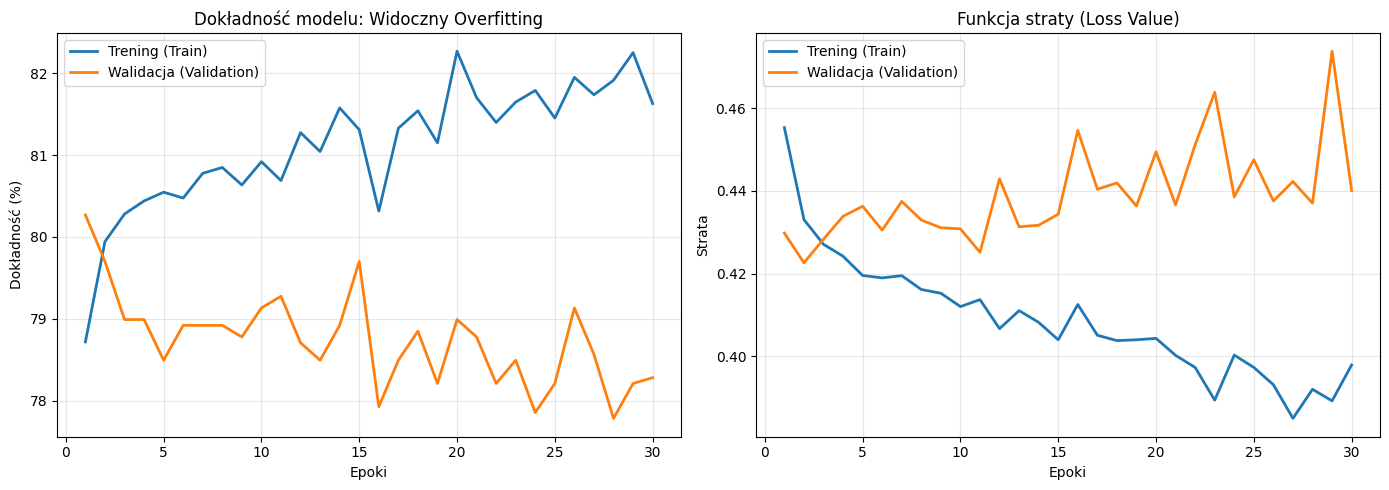

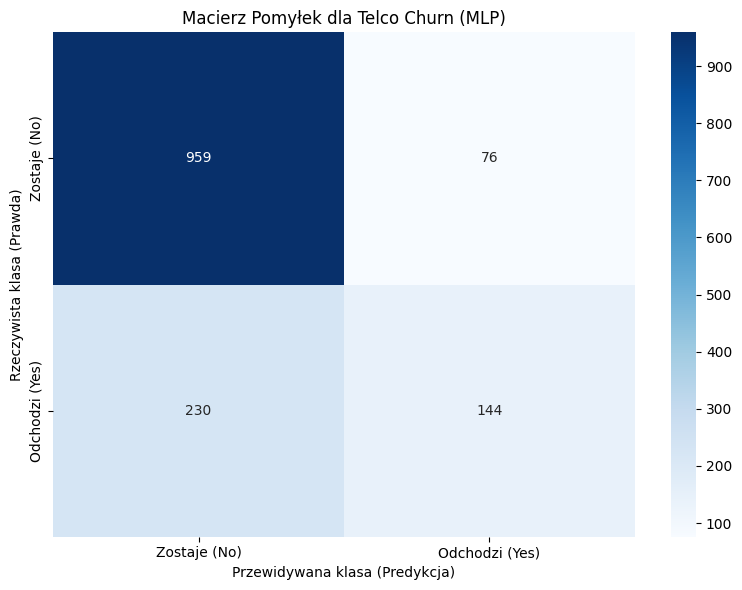

In [4]:
# Ewaluacja i macierz pomyłek
y_true, y_pred, _ = evaluate_best_model(best_model, test_loader, device, target_classes)
plot_single_history_overfitting(history)
plot_confusion_matrix_heatmap(y_true, y_pred, target_classes)
    


### Ocena wykresów i wyników
Wykresy pokazują rosnącą linię straty dla walidacji, co graficznie potwierdza problem przeuczenia się naszej sieci. Z kolei tabela i macierz pomyłek ujawniają, że model dobrze radzi sobie z lojalnymi klientami, ale poprawnie wykrywa tylko 39% osób faktycznie odchodzących z firmy (wskaźnik Recall dla klasy Odchodzi). Sieć neuronowa w tej wersji sztucznie faworyzuje liczniejszą grupę klientów, aby uzyskać ogólną wysoką celność na poziomie 78%.

Seria eksperymentów (execute_series)

>>> TEST SERII: hidden_layers = [32]
Epoch 01 | Train Acc: 77.81% | Val Acc: 78.71% | Val Loss: 0.4346
Epoch 02 | Train Acc: 79.94% | Val Acc: 79.28% | Val Loss: 0.4279
Epoch 03 | Train Acc: 80.30% | Val Acc: 79.28% | Val Loss: 0.4290
Epoch 04 | Train Acc: 79.98% | Val Acc: 79.70% | Val Loss: 0.4326
Epoch 05 | Train Acc: 80.07% | Val Acc: 79.49% | Val Loss: 0.4299
Epoch 06 | Train Acc: 80.40% | Val Acc: 79.13% | Val Loss: 0.4245
Epoch 07 | Train Acc: 80.30% | Val Acc: 79.56% | Val Loss: 0.4223
Epoch 08 | Train Acc: 80.46% | Val Acc: 79.35% | Val Loss: 0.4268
Epoch 09 | Train Acc: 80.35% | Val Acc: 79.56% | Val Loss: 0.4268
Epoch 10 | Train Acc: 80.62% | Val Acc: 79.21% | Val Loss: 0.4331
Epoch 11 | Train Acc: 80.12% | Val Acc: 79.42% | Val Loss: 0.4259
Epoch 12 | Train Acc: 80.30% | Val Acc: 80.06% | Val Loss: 0.4248
Epoch 13 | Train Acc: 80.49% | Val Acc: 79.56% | Val Loss: 0.4235
Epoch 14 | Train Acc: 80.88% | Val Acc: 79.77% | Val Loss: 0.4233
E

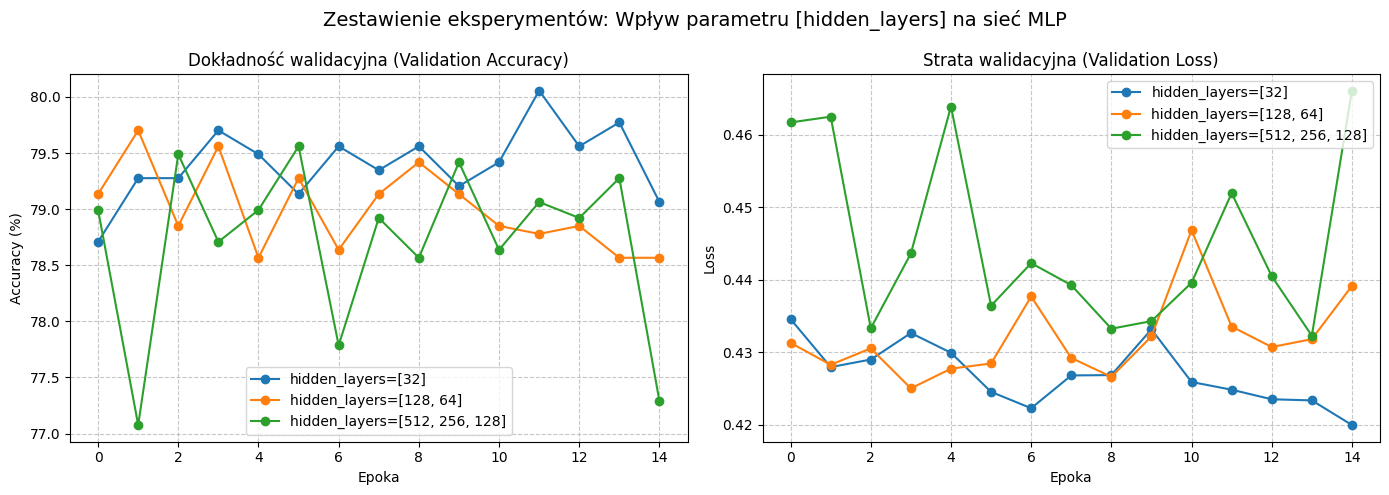

In [5]:
print("Seria eksperymentów (execute_series)")

architektury_testowe = [
    [32],               
    [128, 64],          
    [512, 256, 128]     
]
seria_wynikow = execute_series(
    device=device,
    base_cfg={**base_config, "epochs": 15}, 
    param_name="hidden_layers",
    values=architektury_testowe,
    train_loader=train_loader,
    test_loader=test_loader,
    input_size=input_features_dim
)

plot_series_results(seria_wynikow, "hidden_layers")


### Porównanie struktur sieci
Przetestowanie trzech różnych wielkości sieci wykazało, że najbardziej rozbudowany model [512, 256, 128] osiąga najgorsze wyniki na danych testowych i najszybciej się przeucza. Najlepszą stabilność i najwyższą ogólną celność zaprezentowała najprostsza sieć posiadająca tylko jedną warstwę z 32 neuronami. Udowadnia to, że dokładanie kolejnych warstw i komplikowanie modelu w tym przypadku nie przynosi korzyści, a wręcz szkodzi wynikom.

In [6]:
waga_klas = torch.tensor([2.89]).to(device)

zoptymalizowana_config = {
    "batch_size": 64,               
    "hidden_layers": [32],          
    "dropout": 0.4,                
    "lr": 0.001,                    
    "optimizer_type": "adam",
    "epochs": 15                    
}

In [7]:
history, zoptymalizowany_model = run_experiment(
    device, 
    zoptymalizowana_config, 
    train_loader, 
    test_loader, 
    input_features_dim
)


Epoch 01 | Train Acc: 69.88% | Val Acc: 76.58% | Val Loss: 0.4655
Epoch 02 | Train Acc: 78.40% | Val Acc: 78.21% | Val Loss: 0.4436
Epoch 03 | Train Acc: 79.48% | Val Acc: 78.64% | Val Loss: 0.4358
Epoch 04 | Train Acc: 79.69% | Val Acc: 78.78% | Val Loss: 0.4334
Epoch 05 | Train Acc: 79.66% | Val Acc: 79.13% | Val Loss: 0.4290
Epoch 06 | Train Acc: 79.89% | Val Acc: 78.78% | Val Loss: 0.4286
Epoch 07 | Train Acc: 79.68% | Val Acc: 79.49% | Val Loss: 0.4273
Epoch 08 | Train Acc: 79.93% | Val Acc: 79.49% | Val Loss: 0.4255
Epoch 09 | Train Acc: 80.39% | Val Acc: 79.70% | Val Loss: 0.4249
Epoch 10 | Train Acc: 80.28% | Val Acc: 79.56% | Val Loss: 0.4241
Epoch 11 | Train Acc: 80.51% | Val Acc: 79.70% | Val Loss: 0.4249
Epoch 12 | Train Acc: 80.39% | Val Acc: 79.49% | Val Loss: 0.4245
Epoch 13 | Train Acc: 80.80% | Val Acc: 79.63% | Val Loss: 0.4235
Epoch 14 | Train Acc: 80.60% | Val Acc: 79.21% | Val Loss: 0.4230
Epoch 15 | Train Acc: 80.72% | Val Acc: 79.35% | Val Loss: 0.4233


### Trening zbalansowany
W tej próbie zmniejszyliśmy tempo nauki do 0.001, skróciliśmy czas do 15 epok oraz dodaliśmy specjalne wagi, które zmuszają sieć do zwracania większej uwagi na mniejszościową klasę odchodzących klientów. Dzięki tym zabiegom oraz silniejszemu odrzucaniu neuronów (dropout=0.4) proces uczenia stał się stabilniejszy. Skutecznie ograniczyliśmy zjawisko przeuczenia.

In [8]:
all_targets, all_preds = ewaluacja_i_raport_koncowy(zoptymalizowany_model, test_loader, device, history)

GENEROWANIE RAPORTU KLASYFIKACJI...
Weryfikacja długości - Prawdziwe etykiety: 1409, Przewidywania: 1409

RAPORT KLASYFIKACJI (Classification Report) dla modelu zoptymalizowanego:
                precision    recall  f1-score   support

  Zostaje (No)       0.83      0.89      0.86      1035
Odchodzi (Yes)       0.63      0.51      0.56       374

      accuracy                           0.79      1409
     macro avg       0.73      0.70      0.71      1409
  weighted avg       0.78      0.79      0.78      1409



### Wynik zoptymalizowany

Raport klasyfikacji dla modelu zoptymalizowanego pokazuje udane wyrównanie proporcji: wskaźnik Recall dla trudnej klasy Odchodzi (Yes) wzrósł do poziomu 51%. Oznacza to, że po zastosowaniu wag klas sieć przestała ignorować odchodzących klientów i potrafi wykryć ich zdecydowaną większość. 

Niestety, zmiana ta dokonała się kosztem spadku wskaźnika Precision dla tej klasy do poziomu 63%.

GENEROWANIE WYKRESU MACIERZY POMYŁEK...


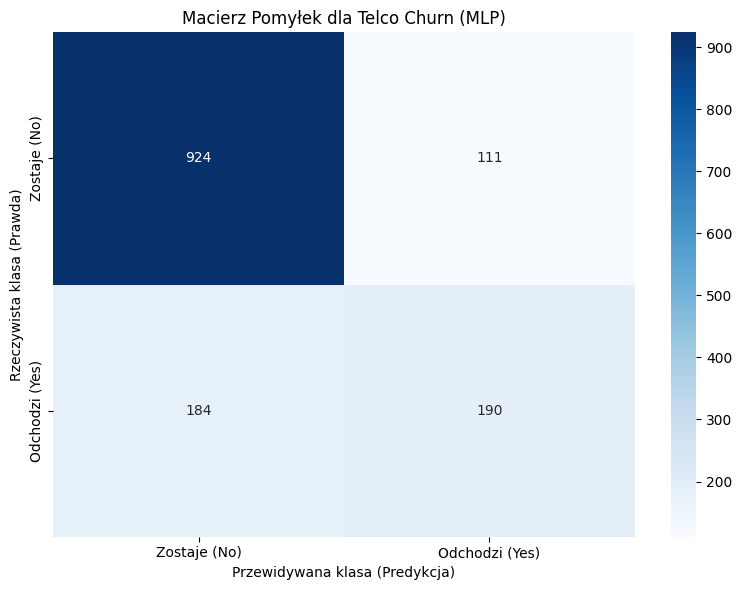

In [9]:
print("GENEROWANIE WYKRESU MACIERZY POMYŁEK...")
plot_confusion_matrix_heatmap(all_targets, all_preds, target_classes)


GENEROWANIE WYKRESU HISTORII UCZENIA...


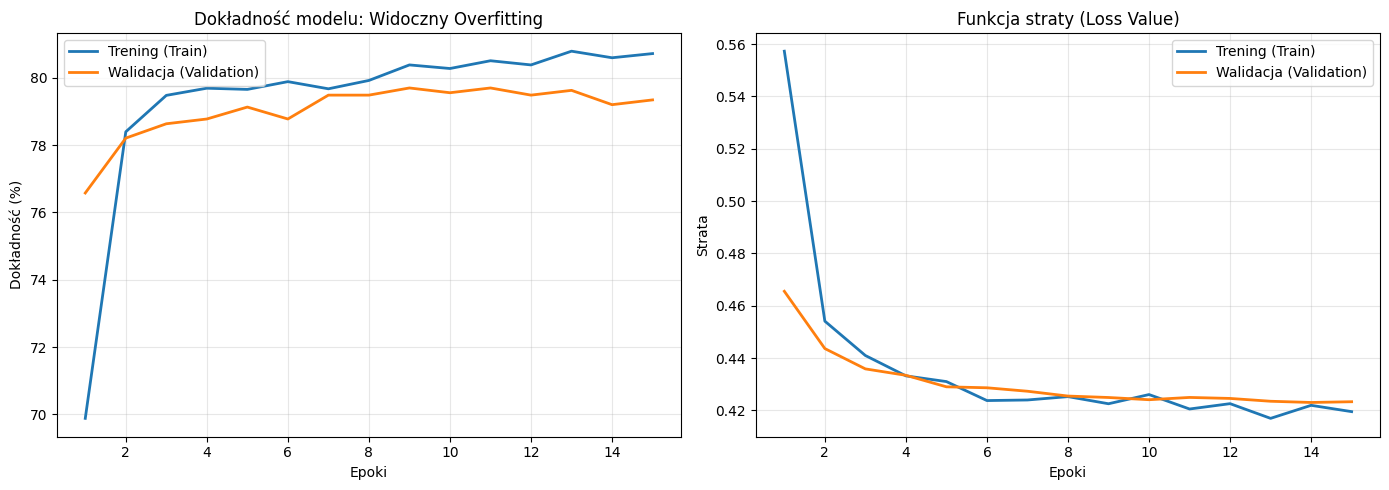

In [10]:
print("\nGENEROWANIE WYKRESU HISTORII UCZENIA...")
plot_single_history_overfitting(history)

### Wynik zoptymalizowany
Wprowadzenie wag sprawiło, że sieć zaczęła znacznie lepiej wykrywać odchodzących klientów. Niestety stało się to kosztem ogromnego spadku wskaźnika Precision, co oznacza, że około połowa alertów o odejściu klienta będzie fałszywym alarmem. Model wpadł w pułapkę kompromisu między precyzją a czułością, z której przy tej architekturze nie da się wyjść.

## Podsumowanie i Wnioski Końcowe

Przeprowadzone badania jednoznacznie dowodzą, że **wielowarstwowa sieć neuronowa (MLP) jest słabym algorytmem do wykorzystania w tym konkretnym przypadku**. 

Zbiór danych Telco Customer Churn opiera się na danych tabelarycznych, w których dominują cechy kategoryczne (tekstowe), a liczba wszystkich wierszy jest stosunkowo niewielka. Sieci neuronowe ze swojej natury potrzebują ogromnych zbiorów z danymi ciągłymi (np. obrazy, dźwięki), aby właściwie wyznaczyć granice decyzji. W tym przypadku nasz model działa skrajnie niestabilnie: albo całkowicie ignoruje odchodzących ludzi, albo po zmianie wag generuje masę fałszywych alarmów, co w biznesie narażałoby firmę na niepotrzebne koszty marketingowe.